**Arbol de Expansión Mínimo: Algoritmo Kruskal**

MST aplicando el Algortimo Kruskal a partir de una lista de adyacencia ponderada.

In [449]:
import graphviz as gv

In [450]:
class Graph:
    def __init__(self, vertices):
        self.V = vertices
        self.graph = []

    def add_edge(self, u, v, w):
        self.graph.append([u, v, w])

    # Funcion de busqueda Union Find

    def find(self, parent, i):
        if parent[i] == i:
            return i
        return self.find(parent, parent[i])

    def apply_union(self, parent, rank, x, y):
        xroot = self.find(parent, x)
        yroot = self.find(parent, y)
        if rank[xroot] < rank[yroot]:
            parent[xroot] = yroot
        elif rank[xroot] > rank[yroot]:
            parent[yroot] = xroot
        else:
            parent[yroot] = xroot
            rank[xroot] += 1

    #  Aplicando del Algortimo Kruskal
    def kruskal_algo(self):
        result = []
        i, e, tot_weight = 0, 0, 0
        self.graph = sorted(self.graph, key=lambda item: item[2])
        parent = []
        rank = []
        for node in range(self.V):
            parent.append(node)
            rank.append(0)
        while e < self.V - 1:
            u, v, w = self.graph[i]
            i = i + 1
            x = self.find(parent, u)
            y = self.find(parent, v)
            if x != y:
                e = e + 1
                result.append([u, v, w])
                self.apply_union(parent, rank, x, y)
        for u, v, weight in result:
            tot_weight = tot_weight + weight
            print("%d - %d: %d" % (u, v, weight))

        return result


Definición de una LA ponderada. Se parte desde la linea 0 y se lee: desde el nodo 0 al nodo 1 hay una arista de peso 4, del nodo 0 hacia el nodo 2 existe un peso de 4, del nodo 2: hacia nodo 0 el peso es de 4, hacia el nodo 1 el peso de 1....

In [451]:
%%file 1.in
1|4 2|4
2|2 0|4
0|4 1|2 3|3 5|2 4|4
2|3 4|3
2|4 3|3
2|2 4|3

Overwriting 1.in


Funciones que permiten leer(readAdjl) y visualizar(adjlShow) una lista de adyacencia.

In [452]:
def readAdjl(fn, haslabels=False, weighted=False, sep="|"):
  with open(fn) as f:
    labels = None
    if haslabels:
      labels = f.readline().strip().split()
    L = []
    for line in f:
      if weighted:
        L.append([tuple(map(int, p.split(sep))) for p in line.strip().split()])
        # line => "1|3 2|5 4|4" ==> [(1, 3), (2, 5), (4, 4)]
      else: 
        L.append(list(map(int, line.strip().split()))) # "1 3 5" => [1, 3, 5]
        # L.append([int(x) for x in line.strip().split()])
  return L, labels

def adjlShow(L, labels=None, directed=False, weighted=False, path=[], layout="sfdp"):
    g = gv.Digraph("G") if directed else gv.Graph("G")
    g.graph_attr["layout"] = layout
    g.edge_attr["color"] = "gray"
    g.node_attr["color"] = "orangered"
    g.node_attr["width"] = "0.1"
    g.node_attr["height"] = "0.1"
    g.node_attr["fontsize"] = "8"
    g.node_attr["fontcolor"] = "mediumslateblue"
    g.node_attr["fontname"] = "monospace"
    g.edge_attr["fontsize"] = "8"
    g.edge_attr["fontname"] = "monospace"
    
    n = len(L)
    for u in range(n):
        g.node(str(u), labels[u] if labels else str(u))
    added = set()
    
    for v, u in path:
        if u is not None:
            if weighted:
                for vi, w in L[u]:
                    if vi == v:
                        break
                g.edge(str(u), str(v), str(w), dir="forward", penwidth="2", color="orange")
            else:
                g.edge(str(u), str(v), dir="forward", penwidth="2", color="orange")
            added.add(f"{u},{v}")
            added.add(f"{v},{u}")
    
    if weighted:
        for u in range(n):
            for v, w in L[u]:
                if not directed and f"{u},{v}" not in added:
                    added.add(f"{u},{v}")
                    added.add(f"{v},{u}")
                    g.edge(str(u), str(v), str(w))
                elif directed:
                    g.edge(str(u), str(v), str(w))
    else:
        for u in range(n):
            for v in L[u]:
                if not directed and f"{u},{v}" not in added:
                    added.add(f"{u},{v}")
                    added.add(f"{v},{u}")
                    g.edge(str(u), str(v))
                elif directed:
                    g.edge(str(u), str(v))
    
    return g

Visualizamos el grafo ponderado a partir de la lista de Adyacencia ponderada contenida en el archivo 1.in

 0: [(1, 4), (2, 4)]
 1: [(2, 2), (0, 4)]
 2: [(0, 4), (1, 2), (3, 3), (5, 2), (4, 4)]
 3: [(2, 3), (4, 3)]
 4: [(2, 4), (3, 3)]
 5: [(2, 2), (4, 3)]


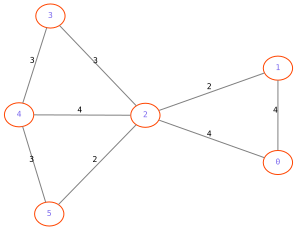

In [453]:
G, _ = readAdjl("1.in", weighted=True)
for i, edges in enumerate(G):
  print(f"{i:2}: {edges}")
adjlShow(G, weighted=True)

Otra forma de crear el grafo y sus aristas ponderadas (sin leer una lista de adyacencia de sde un archivo).

In [454]:
g = Graph(6)
g.add_edge(0, 1, 4)
g.add_edge(0, 2, 4)
g.add_edge(1, 2, 2)
g.add_edge(1, 0, 4)
g.add_edge(2, 0, 4)
g.add_edge(2, 1, 2)
g.add_edge(2, 3, 3)
g.add_edge(2, 5, 2)
g.add_edge(2, 4, 4)
g.add_edge(3, 2, 3)
g.add_edge(3, 4, 3)
g.add_edge(4, 2, 4)
g.add_edge(4, 3, 3)
g.add_edge(5, 2, 2)
g.add_edge(5, 4, 3)


Ejecutamos la funcion del Algoritmo Kruskal, **kruskal_algo()** a fin de obtener el costo total del mst para el grafo G.

In [455]:
g.kruskal_algo()

1 - 2: 2
2 - 5: 2
2 - 3: 3
3 - 4: 3
0 - 1: 4


[[1, 2, 2], [2, 5, 2], [2, 3, 3], [3, 4, 3], [0, 1, 4]]

1 - 2: 2
2 - 5: 2
2 - 3: 3
3 - 4: 3
0 - 1: 4


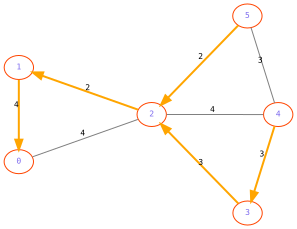

In [456]:
mst = g.kruskal_algo()

# Crear la lista de adyacencia del grafo original
adjacency_list = [[] for _ in range(g.V)]
for u, v, w in g.graph:
    adjacency_list[u].append((v, w))
    adjacency_list[v].append((u, w))  

# Crear la lista de adyacencia del MST
mst_path = [(u, v) for u, v, w in mst]

adjlShow(adjacency_list, weighted=True, path=mst_path)
